416 612 3


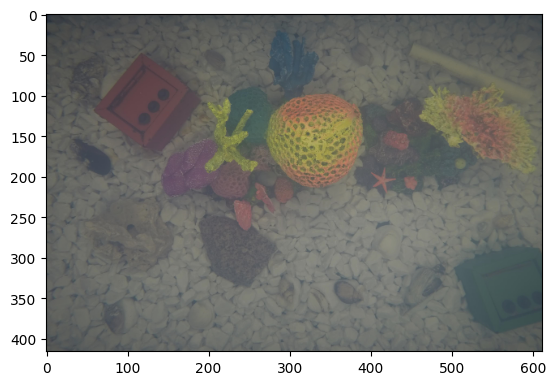

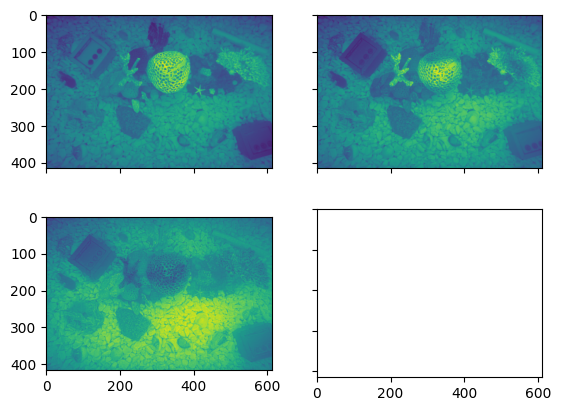

In [97]:
import cv2
from cv2.typing import MatLike
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Iterable
import math

def plt_imgs(imgs: Iterable[MatLike], grouped: bool = True, max_cols: int = 2):
    if grouped:
        num_rows = math.ceil(len(imgs) / max_cols)
        fig, ax = plt.subplots(nrows=num_rows, ncols=max_cols, sharex=True, sharey=True)
        # ax = ax.flatten()
        for r in range(num_rows):
            for c in range(max_cols):
                img_idx = r * max_cols + c
                if img_idx < len(imgs):
                    ax[r, c].imshow(imgs[img_idx])
        plt.show()
    else:
        for img in imgs:
            plt_img(img)

def plt_img(img: MatLike, show_plot: bool = True):
    if len(img.shape) == 3:
        img = img[:,:,::-1]  # Reverse BGR -> RGB
    plt.imshow(img)
    if show_plot:
        plt.show()

PATH = Path('milk') / '8.jpg'

img = cv2.imread(str(PATH))
img = cv2.resize(img, (img.shape[1] // 6, img.shape[0] // 6))

H, W, C = img.shape
print(H, W, C)

plt_img(img)

b, g, r = cv2.split(img)

plt_imgs((r, g, b))

In [ ]:
means = cv2.mean(img)
print(means)

extremes = [(results[0], results[1]) for results in [cv2.minMaxLoc(c) for c in cv2.split(img)]]

# Find large channel l, medium channel m, smallest channel s
channels = [3]  # 4th channel unused == 0.0
for i, intensity in enumerate(means):
    for c, channel in enumerate(channels):
        if means[channel] < intensity:
            channels.insert(c, i)
            break

l, m, s, _ = channels

print(l, m, s)

I_O = (50, 150)  # Output intensity bounds

# Enhance dynamic range of large channel
for row in img:
    for pixel in row:
        pixel[l] = (
            I_O[0] +
            (I_O[1] - I_O[0]) / (extremes[l][1] - extremes[l][0]) *
            (pixel[l] - extremes[l][0])
        )

print(cv2.mean(img))

def color_loss(means, l, m, s):
    return (means[l] - means[m]) + (means[l] - means[s])

while color_loss(:
    for row in img:
        for pixel in row:
            for c in (m, s):
                pixel[c] = (
                    pixel[c] +
                    (means[l] - means[c]) / means[l] *
                    pixel[l]
                )

print(cv2.mean(img))

(98.33166399572649, 103.8474343262946, 103.87635510935142, 0.0)
2 1 0
(98.33166399572649, 103.8474343262946, 90.72920594519859, 0.0)
(102.66876414027148, 103.8474343262946, 90.72920594519859, 0.0)
